In [3]:
import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import Statevector, random_unitary
from qiskit_aer import AerSimulator

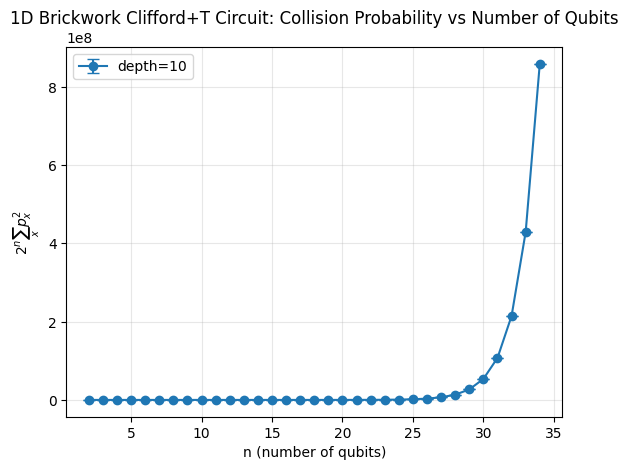

In [18]:
def random_clifford_t_block(qc, i, add_t=True, p_t=0.2):
    for q in [i, i + 1]:
        r = np.random.randint(4)
        if r == 0:
            qc.h(q)
        elif r == 1:
            qc.s(q)
        elif r == 2:
            qc.h(q)
            qc.s(q)

    if np.random.rand() < 0.5:
        qc.cx(i, i + 1)
    else:
        qc.cx(i + 1, i)

    if add_t:
        if np.random.rand() < p_t:
            qc.t(i)
        if np.random.rand() < p_t:
            qc.t(i + 1)

def build_circuit(n, d, add_t=True, p_t=0.2):
    qc = QuantumCircuit(n, n)
    for layer in range(d):
        start = layer % 2
        for i in range(start, n - 1, 2):
            random_clifford_t_block(qc, i, add_t=add_t, p_t=p_t)
    qc.measure(range(n), range(n))
    return qc

def collision_prob(counts, shots):
    probs = np.array(list(counts.values())) / shots
    return np.sum(probs**2)

sim = AerSimulator(method="extended_stabilizer")

depth = [10]
num_qubits = list(range(2, 35))
shots = 20
samples_per_n = 10

for d in depth:
    avg_prob = []
    std_prob = []

    for n in num_qubits:
        vals = []
        for _ in range(samples_per_n):
            qc = build_circuit(n, d, add_t=False, p_t=0.15)

            # Force a Clifford+T-friendly basis
            tqc = transpile(
                qc,
                basis_gates=['h', 's', 'sdg', 't', 'tdg', 'cx', 'measure'],
                optimization_level=0
            )

            qc.draw(output='mpl', fold=-1)

            result = sim.run(
                tqc,
                shots=shots
            ).result()

            counts = result.get_counts()
            cp_est = collision_prob(counts, shots)
            vals.append((2**n) * cp_est)

        avg_prob.append(np.mean(vals))
        std_prob.append(np.std(vals))

    plt.errorbar(num_qubits, avg_prob, yerr=std_prob, marker='o', capsize=4, label=f"depth={d}")

plt.xlabel("n (number of qubits)")
plt.ylabel(r"$2^n \sum_x p_x^2$")
plt.title("1D Brickwork Clifford+T Circuit: Collision Probability vs Number of Qubits")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()